In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

##open photos
photo_folder = 'output_folder' ##replace path with path to folder with photos to process
photos = []
undistorted_photos = []
num_photos = len(os.listdir(photo_folder))

##open .csv file with pose and timestep
pose_file = 'lab3_pose.csv' ##replace with path to .csv file with pose and timestep data
pose_data = np.genfromtxt(pose_file, delimiter=',', skip_header=1)
#1-idx, 2-px, 3-py, 4-pz, 5-qw, 6-qx, 7-qy, 8-qz
# print(f"pose data: {pose_data[8:12]}") ##check data input is correct from csv file
##landmark pixel coordinates
##must be within x=y= {-2, 2} [m] in body frame
landmark_px = []
landmark_body = []

In [2]:
##camera parameters from lab 3 document on quercus
K = np.matrix([[698.86, 0, 306.91],[0, 699.13, 150.34],[0, 0, 1]])
d = np.array([0.191887, -0.563680, -0.003676, -0.002037, 0])
Tcb = np.matrix([[1, -1, 0, 0],[-1, 0, 0, 0],[0, 0, -1, 0],[0, 0, 0, 1]])

In [ ]:
##loop through photos to undistort and find contours of landmarks
thresh_photos = [] ##clear cache

for i in range(800, 900):
    #open photos and store in list
    photo_path = os.path.join(photo_folder, f'image_{i}.jpg')
    photo = cv2.imread(photo_path)
    photos.append(photo)

    ##apply camera distorion parameters and greyscale to photos
    photo = cv2.undistort(photo, K, d)
    photo = cv2.cvtColor(photo, cv2.COLOR_BGR2GRAY)
    photo = cv2.GaussianBlur(photo, (5, 5), 0)
    undistorted_photos.append(photo)
    # After Gaussian Blur, create a binary mask
    # Adjust 200 based on your lighting; pixels above 200 become white (255)
    ret, thresh = cv2.threshold(photo, 120, 255, cv2.THRESH_BINARY)
    thresh_photos.append(thresh)



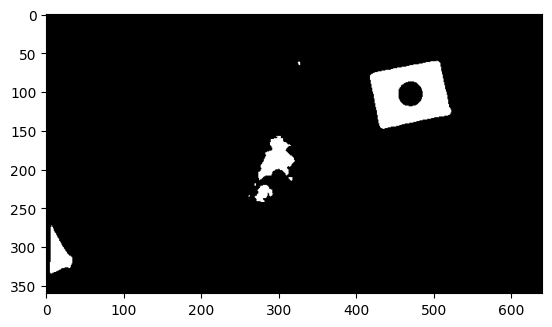

In [4]:
imgbrg = thresh_photos[50]
imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
plt.imshow(imgrgb)
plt.show()

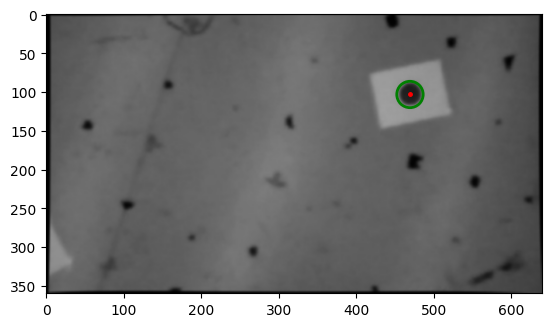

In [5]:
## find contour, identify circle, then plot the circle on the undistored photo
contours, hierarchy = cv2.findContours(thresh_photos[50], cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
imgbrg = undistorted_photos[50]
imgrgb = cv2.cvtColor(imgbrg, cv2.COLOR_BGR2RGB)
plt.imshow(imgrgb)
if hierarchy is not None and len(contours) > 0:
    for i, contour in enumerate(contours):
        
        # hierarchy[0][i] contains an array: [Next, Previous, First_Child, Parent]
        # We want to look at the 'Parent' index (which is at index 3)
        parent_idx = hierarchy[0][i][3]
        
        # 4. If parent_idx is NOT -1, it means this contour is INSIDE another contour
        if parent_idx != -1:
            
            # 5. Filter out tiny specks of noise that might be inside the square
            if cv2.contourArea(contour) > 10: 
                
                # We found the inner dot! Calculate its circle.
                (x, y), radius = cv2.minEnclosingCircle(contour)
                center = (int(x), int(y))
                radius = int(radius)
                
                # draw the circle with matplotlib instead of cv2
                # (assumes the image has already been shown with plt.imshow
                #  – you can call plt.show() again after the loop to render
                #  the patches)
                circ = plt.Circle(center, radius,
                                  edgecolor='g', facecolor='none', linewidth=2)
                plt.gca().add_patch(circ)

                # optional: mark the exact centre with a red dot
                plt.plot(center[0], center[1], 'r.', markersize=5)

plt.show()

Transform images from camera frame to body frame